# 02 - Train SE-ResNeXt-50 on the Original 224x224 Dataset

Run notebook 01 first. This is the SE-ResNeXt equivalent of DenseNet notebook
02. It trains only on the published `kneeKL224` images and selects a CE
native-CAM checkpoint from validation. Notebook 03 adapts that checkpoint to
the exact YOLO ROI domain.

The data, augmentation, sampler, loss, input size, three-stage schedule, and
validation selector are locked to DenseNet notebook 02. The only intended
difference is the SE-ResNeXt native-CAM head.


## Execution

Run every cell from top to bottom in a fresh Colab GPU runtime. The dataset is
extracted from Drive when the archive exists. The notebook trains on `train`,
selects checkpoints only on `val`, and evaluates `test` once after selection.


In [9]:
import csv
import hashlib
import json
import os
import random
import subprocess
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import tqdm
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    precision_recall_fscore_support,
    recall_score,
    roc_auc_score,
)
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    print("Not running in Colab; Drive mount skipped.")

try:
    import timm
except ImportError:
    subprocess.run(["pip", "install", "-q", "timm"], check=True)
    import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

SEED = 42
INPUT_SIZE = 384
BATCH_SIZE = 48
NUM_WORKERS = 2
DATASET_ROOT = Path("/content/drive/MyDrive/Datasets/KneeXrayData_Mendeley_v1/extracted/KneeXrayData/ClsKLData/kneeKL224")
RUN_TIMESTAMP = datetime.now(timezone.utc).strftime("%Y-%m-%d_%H-%M-%S_%f_UTC")
RUN_DIR = Path("/content/drive/MyDrive/Models/seresnext50_32x4d_checkpoints") / f"{RUN_TIMESTAMP}_original_224_ce_3stage"
if not DATASET_ROOT.is_dir():
    raise FileNotFoundError(f"Original 224 dataset not found: {DATASET_ROOT}")
RUN_DIR.mkdir(parents=True, exist_ok=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
print(f"Device: {device}")
print(f"Run directory: {RUN_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: Tesla T4
Device: cuda
Run directory: /content/drive/MyDrive/Models/seresnext50_32x4d_checkpoints/2026-08-01_03-46-16_723682_UTC_original_224_ce_3stage


## Data Preparation

The published `kneeKL224` train/val/test folders are used unchanged and are
deduplicated across splits. There is no deterministic knee mirroring or center
crop. Horizontal flip is training-only augmentation, exactly as in DenseNet.


In [10]:
class SquarePad:
    def __call__(self, image):
        height, width = image.shape[:2]
        side = max(height, width)
        top = (side - height) // 2
        bottom = side - height - top
        left = (side - width) // 2
        right = side - width - left
        return cv2.copyMakeBorder(
            image,
            top,
            bottom,
            left,
            right,
            cv2.BORDER_CONSTANT,
            value=[0, 0, 0],
        )


class CLAHE:
    def __call__(self, image):
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        lightness, channel_a, channel_b = cv2.split(lab)
        lightness = cv2.createCLAHE(
            clipLimit=1.25, tileGridSize=(8, 8)
        ).apply(lightness)
        return cv2.cvtColor(
            cv2.merge((lightness, channel_a, channel_b)),
            cv2.COLOR_LAB2RGB,
        )


class RandomGammaCorrection:
    """Apply mild gamma correction with a reproducible training-only probability."""

    def __init__(self, gamma_range=(0.90, 1.10), probability=0.20):
        low, high = gamma_range
        if low <= 0 or high < low:
            raise ValueError("gamma_range must contain positive ordered values")
        if not 0.0 <= probability <= 1.0:
            raise ValueError("probability must be between 0 and 1")
        self.gamma_range = (float(low), float(high))
        self.probability = float(probability)

    def __call__(self, image):
        if torch.rand(1).item() >= self.probability:
            return image
        gamma = torch.empty(1).uniform_(*self.gamma_range).item()
        return transforms.functional.adjust_gamma(image, gamma=gamma, gain=1.0)


train_transform = transforms.Compose([
    CLAHE(),
    SquarePad(),
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.50),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.08, contrast=0.08),
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.RandomErasing(
        p=0.10, scale=(0.02, 0.05), ratio=(0.5, 2.0), value=0
    ),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

evaluation_transform = transforms.Compose([
    CLAHE(),
    SquarePad(),
    transforms.ToPILImage(),
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


def file_digest(path):
    digest = hashlib.sha256()
    with open(path, "rb") as image_file:
        for chunk in iter(lambda: image_file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


class KneeDataset(Dataset):
    def __init__(self, split, transform, excluded_hashes=None):
        self.transform = transform
        split_dir = DATASET_ROOT / split
        if not split_dir.is_dir():
            raise FileNotFoundError(f"Dataset split is missing: {split_dir}")

        excluded_hashes = excluded_hashes or set()
        retained_hashes = set()
        self.paths = []
        self.labels = []
        for grade in range(5):
            grade_dir = split_dir / str(grade)
            for path in sorted(grade_dir.iterdir()):
                if path.suffix.lower() not in {".png", ".jpg", ".jpeg"}:
                    continue
                digest = file_digest(path)
                if digest in excluded_hashes or digest in retained_hashes:
                    continue
                retained_hashes.add(digest)
                self.paths.append(str(path))
                self.labels.append(grade)
        self.image_hashes = retained_hashes
        print(f"{split}: {len(self.paths)} unique images")

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        path = self.paths[index]
        image = cv2.imread(path)
        if image is None:
            raise IOError(f"Could not read image: {path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        return self.transform(image), self.labels[index], path


In [11]:
train_dataset = KneeDataset("train", train_transform)
validation_dataset = KneeDataset(
    "val", evaluation_transform, train_dataset.image_hashes
)

class_counts = Counter(train_dataset.labels)
sample_weights = [
    1.0 / class_counts[label] for label in train_dataset.labels
]
sampler_generator = torch.Generator().manual_seed(42)
balanced_sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
    generator=sampler_generator,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=balanced_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    generator=sampler_generator,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
)
print("Class counts:", dict(sorted(class_counts.items())))
print(
    f"Batches: train={{len(train_loader)}}, "
    f"validation={{len(validation_loader)}}"
)


train: 5778 unique images
val: 826 unique images
Class counts: {0: 2286, 1: 1046, 2: 1516, 3: 757, 4: 173}
Batches: train={len(train_loader)}, validation={len(validation_loader)}


## Model: `final_native_cam_ce`

SE-ResNeXt-50 exposes its final semantic feature tensor. A 1x1 convolution produces
five grade maps, and global average pooling produces the logits. Orientation policy is
recorded separately from the unchanged spatially linear native-CAM head.


In [12]:
class SEResNeXt50NativeCAM(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            "seresnext50_32x4d",
            pretrained=pretrained,
            features_only=True,
            out_indices=(4,),
        )
        channels = self.backbone.feature_info.channels()[0]
        self.class_conv = nn.Conv2d(channels, 5, kernel_size=1)

    def class_maps(self, images):
        return self.class_conv(self.backbone(images)[0])

    def forward(self, images):
        return self.class_maps(images).mean(dim=(2, 3))

    def native_cam(self, images, class_indices=None):
        with torch.no_grad():
            maps = self.class_maps(images)
            logits = maps.mean(dim=(2, 3))
            if class_indices is None:
                class_indices = logits.argmax(dim=1)
            class_indices = torch.as_tensor(
                class_indices, device=images.device, dtype=torch.long
            ).reshape(-1)
            selected = maps[
                torch.arange(images.size(0), device=images.device),
                class_indices,
            ]
            selected = F.relu(selected).unsqueeze(1)
            selected = F.interpolate(
                selected,
                size=images.shape[-2:],
                mode="bilinear",
                align_corners=False,
            ).squeeze(1)
            maxima = selected.flatten(1).amax(1).clamp_min(1e-8)
            selected = selected / maxima[:, None, None]
        return selected, logits

    def freeze_backbone(self):
        for parameter in self.backbone.parameters():
            parameter.requires_grad = False
        for parameter in self.class_conv.parameters():
            parameter.requires_grad = True

    def unfreeze_final_stages(self):
        for parameter in self.parameters():
            parameter.requires_grad = False
        matched = 0
        for name, parameter in self.backbone.named_parameters():
            if any(token in name for token in ("layer3", "layer4", "stages.2", "stages.3")):
                parameter.requires_grad = True
                matched += parameter.numel()
        if matched == 0:
            raise RuntimeError("Could not resolve the final backbone stages.")
        for parameter in self.class_conv.parameters():
            parameter.requires_grad = True

    def unfreeze_all(self):
        for parameter in self.parameters():
            parameter.requires_grad = True


## Training and Validation

Training is fixed to three stages: five head-only epochs, fifteen final-stage
epochs, and ten full fine-tuning epochs. Checkpoint selection uses validation QWK,
macro F1/recall, Grade 1 recall, average precision, and AUC. No test result is used
during optimization or checkpoint selection.


In [13]:
def calculate_metrics(labels, predictions, probabilities):
    labels = np.asarray(labels)
    predictions = np.asarray(predictions)
    probabilities = np.asarray(probabilities)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, labels=[0, 1, 2, 3, 4],
        average="macro", zero_division=0
    )
    one_hot = np.eye(5)[labels]
    metrics = {
        "accuracy": float(accuracy_score(labels, predictions)),
        "qwk": float(cohen_kappa_score(labels, predictions, weights="quadratic")),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(f1),
        "grade1_recall": float(
            recall_score(labels == 1, predictions == 1, zero_division=0)
        ),
        "macro_ap": float(
            average_precision_score(one_hot, probabilities, average="macro")
        ),
        "macro_auc": float(
            roc_auc_score(one_hot, probabilities, average="macro")
        ),
    }
    metrics["selection_score"] = float(
        0.55 * metrics["qwk"]
        + 0.30 * metrics["macro_f1"]
        + 0.15 * metrics["macro_ap"]
    )
    return metrics


def train_one_epoch(model, loader, optimizer, scaler, description):
    model.train()
    running_loss = 0.0
    for images, labels, _ in tqdm.tqdm(loader, desc=description, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(
            device_type=device.type,
            enabled=device.type == "cuda",
        ):
            loss = F.cross_entropy(model(images), labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * labels.size(0)
    return running_loss / len(loader.dataset)


def evaluate(model, loader, description):
    model.eval()
    labels_all, predictions_all, probabilities_all, paths_all = [], [], [], []
    total_loss = 0.0
    with torch.no_grad():
        for images, labels, paths in tqdm.tqdm(loader, desc=description, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(images)
            probabilities = F.softmax(logits.float(), dim=1)
            total_loss += F.cross_entropy(logits, labels).item() * labels.size(0)
            labels_all.extend(labels.cpu().numpy())
            predictions_all.extend(probabilities.argmax(1).cpu().numpy())
            probabilities_all.extend(probabilities.cpu().numpy())
            paths_all.extend(paths)
    metrics = calculate_metrics(
        labels_all, predictions_all, probabilities_all
    )
    metrics["loss"] = total_loss / len(loader.dataset)
    return (
        metrics,
        np.asarray(labels_all),
        np.asarray(predictions_all),
        np.asarray(probabilities_all),
        paths_all,
    )


def load_checkpoint(path):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


In [14]:
model = SEResNeXt50NativeCAM(pretrained=True).to(device)
scaler = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")
stage2_path = RUN_DIR / "stage2_best_model.pth"
best_path = RUN_DIR / "best_model.pth"
last_path = RUN_DIR / "last_model.pth"
history = []
best_stage2_score = -float("inf")
best_selection_score = -float("inf")
global_epoch = 0

for stage_name, stage_epochs in (("warmup", 5), ("coarse", 15), ("finetune", 10)):
    if stage_name == "warmup":
        model.freeze_backbone()
        optimizer = optim.AdamW(
            model.class_conv.parameters(), lr=3e-4, weight_decay=1e-4
        )
        scheduler = None
    elif stage_name == "coarse":
        model.unfreeze_final_stages()
        optimizer = optim.AdamW(
            [
                {
                    "params": [
                        parameter for parameter in model.backbone.parameters()
                        if parameter.requires_grad
                    ],
                    "lr": 3e-5,
                },
                {"params": model.class_conv.parameters(), "lr": 3e-4},
            ],
            weight_decay=1e-4,
        )
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=15, eta_min=1e-7
        )
    else:
        if not stage2_path.exists():
            raise FileNotFoundError("Stage 2 did not produce a checkpoint.")
        model.load_state_dict(load_checkpoint(stage2_path)["model_state_dict"])
        model.unfreeze_all()
        optimizer = optim.AdamW(
            model.parameters(), lr=1e-5, weight_decay=1e-3
        )
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=10, eta_min=1e-7
        )

    for stage_epoch in range(stage_epochs):
        global_epoch += 1
        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            scaler,
            f"{stage_name} {stage_epoch + 1}/{stage_epochs}",
        )
        validation_metrics, _, _, _, _ = evaluate(
            model, validation_loader, "VALIDATE"
        )
        history.append({
            "epoch": global_epoch,
            "stage": stage_name,
            "train_loss": train_loss,
            **validation_metrics,
        })
        print(
            f"Epoch {global_epoch:02d} | {stage_name} | "
            f"QWK={validation_metrics['qwk']:.4f} | "
            f"F1={validation_metrics['macro_f1']:.4f} | "
            f"G1R={validation_metrics['grade1_recall']:.4f} | "
            f"AP={validation_metrics['macro_ap']:.4f} | "
            f"selection={validation_metrics['selection_score']:.4f}"
        )
        if scheduler is not None:
            scheduler.step()

        payload = {
            "model_state_dict": model.state_dict(),
            "epoch": global_epoch,
            "stage": stage_name,
            "architecture": "final_native_cam_ce",
            "model_name": "seresnext50_32x4d",
            "loss_type": "ce",
            "validation_metrics": validation_metrics,
            "history": history,
            "run_timestamp": RUN_TIMESTAMP,
            "fixed_production_config": {
                "input_resize": 384,
                "input_crop": 384,
                "batch_size": 48,
                "sampler": "full_inverse_frequency",
                "canonicalize_laterality": False,
                "horizontal_flip_probability": 0.50,
                "gamma_probability": 0.0,
                "gamma_range": [1.0, 1.0],
                "gaussian_noise_probability": 0.0,
                "stage_epochs": [5, 15, 10],
                "learning_rates": [3e-4, 3e-5, 1e-5],
                "native_cam": True,
            },
        }
        if stage_name == "coarse" and validation_metrics["selection_score"] > best_stage2_score:
            best_stage2_score = validation_metrics["selection_score"]
            torch.save(payload, stage2_path)
        if (
            stage_name in {"coarse", "finetune"}
            and validation_metrics["selection_score"] > best_selection_score
        ):
            best_selection_score = validation_metrics["selection_score"]
            torch.save(payload, best_path)
        torch.save(payload, last_path)

if not best_path.exists():
    raise RuntimeError("Training finished without a final checkpoint.")
with open(RUN_DIR / "epoch_metrics.csv", "w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=history[0].keys())
    writer.writeheader()
    writer.writerows(history)
print(f"Selected checkpoint: {best_path}")


Epoch 01 | warmup | QWK=0.3213 | F1=0.2580 | G1R=0.4967 | AP=0.3037 | selection=0.2997


Epoch 02 | warmup | QWK=0.3085 | F1=0.2169 | G1R=0.0523 | AP=0.3323 | selection=0.2846


Epoch 03 | warmup | QWK=0.3322 | F1=0.2499 | G1R=0.5752 | AP=0.3499 | selection=0.3102


Epoch 04 | warmup | QWK=0.3362 | F1=0.2542 | G1R=0.2026 | AP=0.3557 | selection=0.3145


Epoch 05 | warmup | QWK=0.3910 | F1=0.2975 | G1R=0.2353 | AP=0.3622 | selection=0.3586


...

Epoch 26 | finetune | QWK=0.7875 | F1=0.6658 | G1R=0.3987 | AP=0.6963 | selection=0.7373


Epoch 27 | finetune | QWK=0.7934 | F1=0.6553 | G1R=0.4183 | AP=0.6965 | selection=0.7375


Epoch 28 | finetune | QWK=0.7866 | F1=0.6495 | G1R=0.3922 | AP=0.6951 | selection=0.7318


Epoch 29 | finetune | QWK=0.7903 | F1=0.6592 | G1R=0.3856 | AP=0.6963 | selection=0.7369


Epoch 30 | finetune | QWK=0.7939 | F1=0.6568 | G1R=0.3987 | AP=0.6973 | selection=0.7382
Selected checkpoint: /content/drive/MyDrive/Models/seresnext50_32x4d_checkpoints/2026-08-01_03-46-16_723682_UTC_original_224_ce_3stage/best_model.pth


## Locked Test Evaluation

The test split is loaded only after the validation-selected checkpoint exists.
Predictions and probabilities are saved so the report can be reproduced without
rerunning inference.


test: 1656 unique images


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
TEST:   0%|          | 0/35 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality(

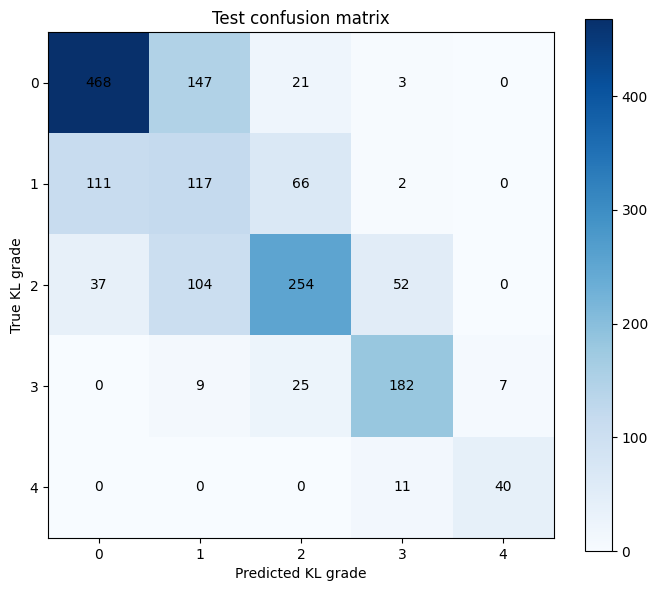

{
  "accuracy": 0.6407004830917874,
  "qwk": 0.8223581631251009,
  "macro_precision": 0.6686275976303905,
  "macro_recall": 0.6592709043815781,
  "macro_f1": 0.6608484834311651,
  "grade1_recall": 0.3952702702702703,
  "macro_ap": 0.7097864650768061,
  "macro_auc": 0.8888746472301694,
  "selection_score": 0.757019504509676,
  "loss": 0.8030115072278009
}
              precision    recall  f1-score   support

     Grade 0       0.76      0.73      0.75       639
     Grade 1       0.31      0.40      0.35       296
     Grade 2       0.69      0.57      0.62       447
     Grade 3       0.73      0.82      0.77       223
     Grade 4       0.85      0.78      0.82        51

    accuracy                           0.64      1656
   macro avg       0.67      0.66      0.66      1656
weighted avg       0.66      0.64      0.65      1656



In [15]:
test_dataset = KneeDataset(
    "test",
    evaluation_transform,
    train_dataset.image_hashes | validation_dataset.image_hashes,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=48,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
)

best_checkpoint = load_checkpoint(best_path)
model.load_state_dict(best_checkpoint["model_state_dict"])
model.eval()
test_metrics, test_true, test_predicted, test_probabilities, test_paths = evaluate(
    model, test_loader, "TEST"
)

prediction_rows = []
for path, true_grade, predicted_grade, probabilities in zip(
    test_paths, test_true, test_predicted, test_probabilities
):
    prediction_rows.append({
        "path": path,
        "true_grade": int(true_grade),
        "predicted_grade": int(predicted_grade),
        **{
            f"grade_{grade}_probability": float(probabilities[grade])
            for grade in range(5)
        },
    })
with open(RUN_DIR / "test_predictions.csv", "w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=prediction_rows[0].keys())
    writer.writeheader()
    writer.writerows(prediction_rows)
with open(RUN_DIR / "test_metrics.json", "w") as handle:
    json.dump(test_metrics, handle, indent=2)

matrix = confusion_matrix(test_true, test_predicted, labels=[0, 1, 2, 3, 4])
figure, axis = plt.subplots(figsize=(7, 6))
image = axis.imshow(matrix, cmap="Blues")
for row in range(5):
    for column in range(5):
        axis.text(column, row, matrix[row, column], ha="center", va="center")
axis.set(
    title="Test confusion matrix",
    xlabel="Predicted KL grade",
    ylabel="True KL grade",
    xticks=range(5),
    yticks=range(5),
)
figure.colorbar(image, ax=axis)
figure.tight_layout()
figure.savefig(RUN_DIR / "test_confusion_matrix.png", dpi=180)
plt.show()

print(json.dumps(test_metrics, indent=2))
print(classification_report(
    test_true,
    test_predicted,
    labels=[0, 1, 2, 3, 4],
    target_names=[f"Grade {grade}" for grade in range(5)],
    zero_division=0,
))


## Grad-CAM Audit

This audit uses post-hoc Grad-CAM from the final SE-ResNeXt feature tensor.
It evaluates up to 50 validation knees per grade and creates predicted-class
and true-class Grad-CAMs for the most anatomically concerning cases. The joint
band is only a coarse anatomical proxy, not lesion segmentation.


GRAD-CAM AUDIT: 100%|██████████| 227/227 [00:30<00:00,  7.43it/s]


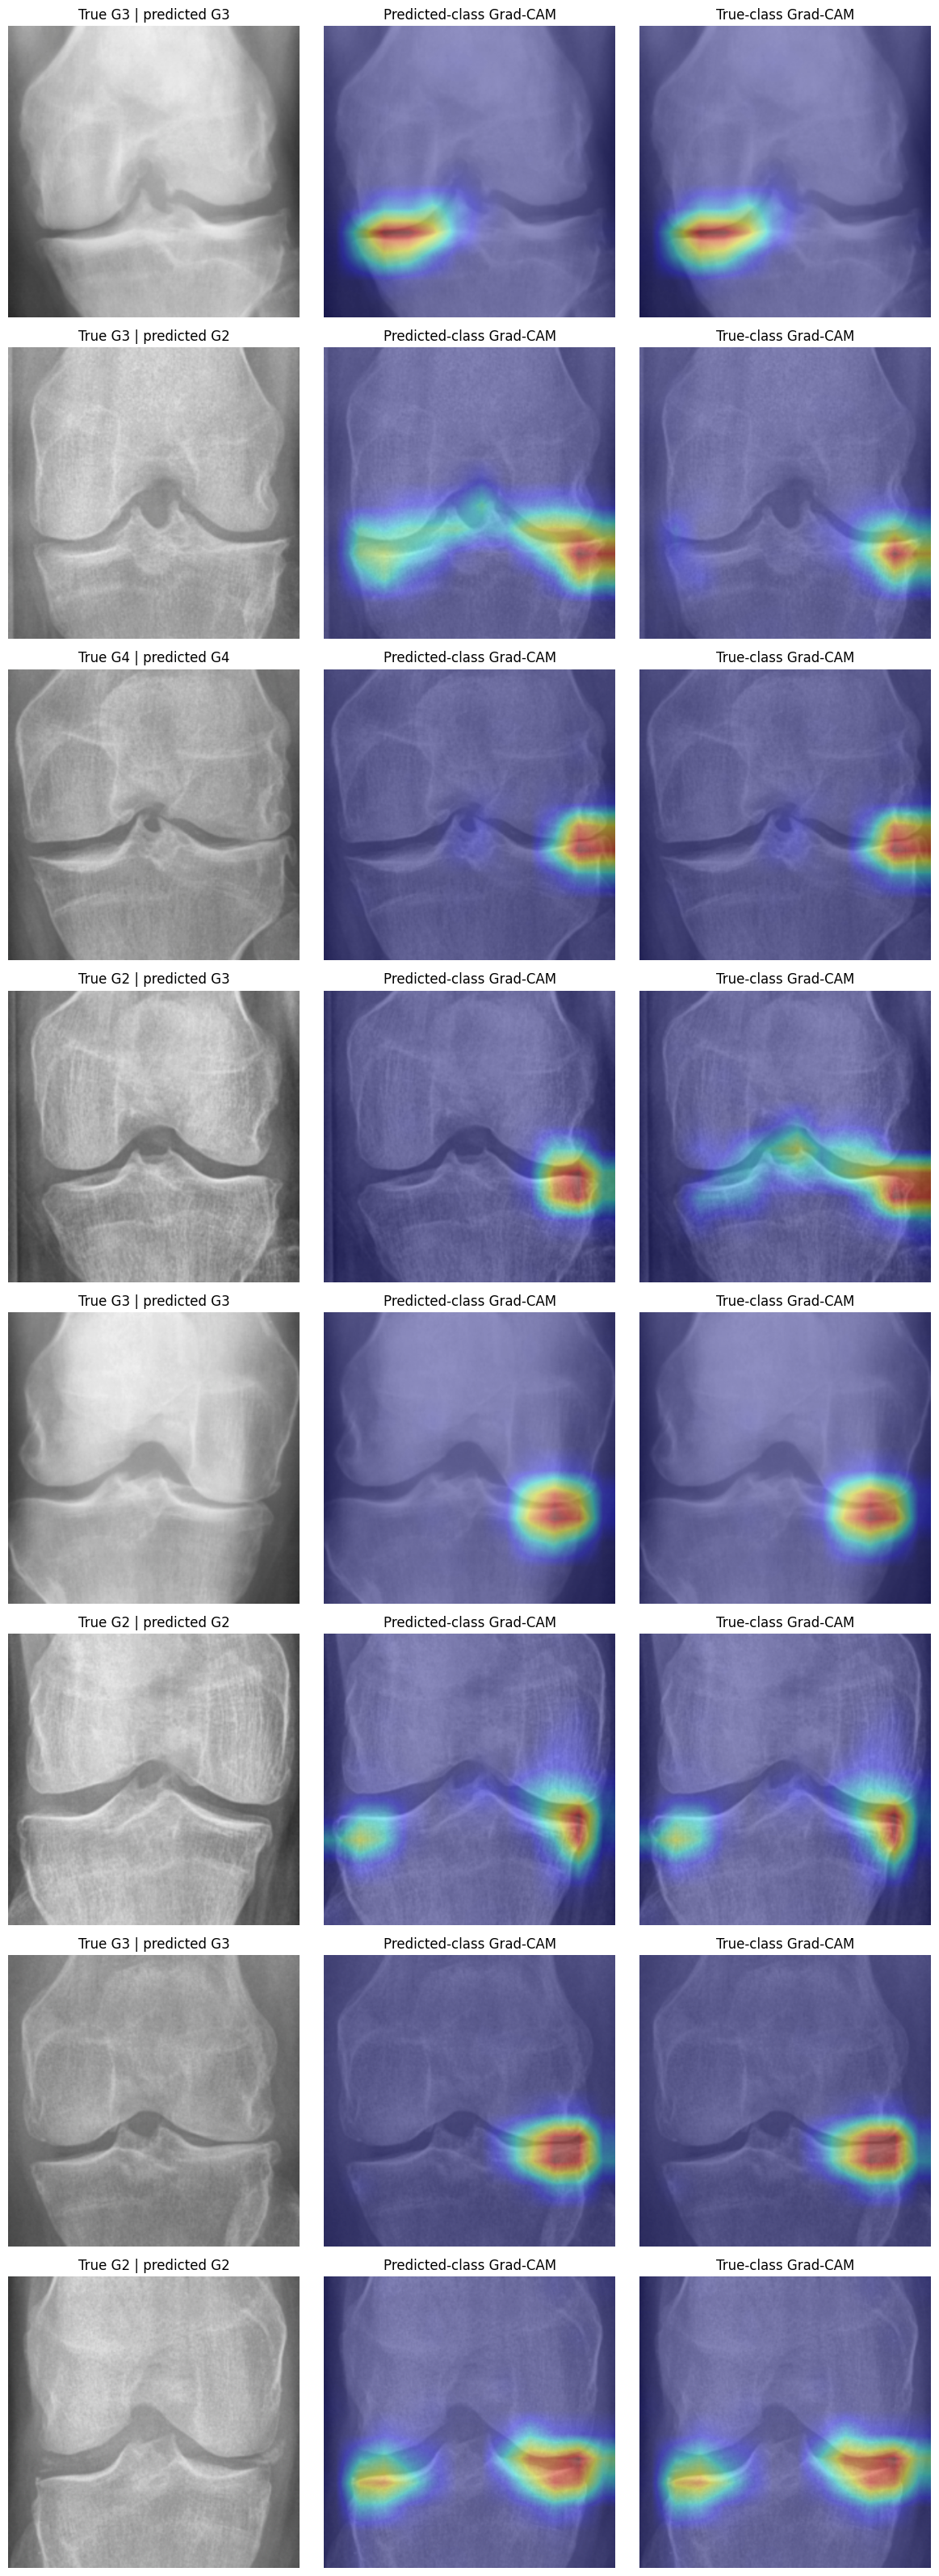

{
  "audited_cases": 227,
  "joint_energy": 0.8783795801394105,
  "border_energy": 0.07431300275934832,
  "lower_tibia_energy": 0.07738085824418277,
  "peak_inside_joint_rate": 1.0
}


In [16]:
class SEGradCAM:
    # Capture the final SE-ResNeXt feature tensor and backpropagate one logit.
    def __init__(self, model):
        self.model = model
        self.activations = None
        self.handle = model.backbone.register_forward_hook(self._capture)

    def _capture(self, module, inputs, output):
        self.activations = output[0] if isinstance(output, (list, tuple)) else output
        if self.activations.requires_grad:
            self.activations.retain_grad()

    def __call__(self, images, class_index):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(images)
        logits[:, class_index].sum().backward()
        weights = self.activations.grad.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=images.shape[-2:], mode="bilinear", align_corners=False)[0, 0]
        cam = cam.detach().cpu().numpy()
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    def remove(self):
        self.handle.remove()


def cam_geometry(cam):
    height, width = cam.shape
    joint = np.zeros((height, width), dtype=bool)
    joint[int(0.28 * height):int(0.72 * height), int(0.06 * width):int(0.94 * width)] = True
    border = np.ones((height, width), dtype=bool)
    border[int(0.08 * height):int(0.92 * height), int(0.08 * width):int(0.92 * width)] = False
    lower_tibia = np.zeros((height, width), dtype=bool)
    lower_tibia[int(0.72 * height):, :] = True
    total = float(cam.sum()) + 1e-8
    peak = np.unravel_index(np.argmax(cam), cam.shape)
    return {"joint_energy": float(cam[joint].sum()) / total, "border_energy": float(cam[border].sum()) / total, "lower_tibia_energy": float(cam[lower_tibia].sum()) / total, "peak_inside_joint": int(joint[peak])}


rng = np.random.default_rng(SEED)
audit_indices = []
labels_array = np.asarray(validation_dataset.labels)
for grade in range(5):
    grade_indices = np.flatnonzero(labels_array == grade)
    rng.shuffle(grade_indices)
    audit_indices.extend(grade_indices[:min(50, len(grade_indices))].tolist())

gradcam = SEGradCAM(model)
cam_rows, cached_maps = [], {}
for index in tqdm.tqdm(audit_indices, desc="GRAD-CAM AUDIT"):
    tensor, true_grade, path = validation_dataset[index]
    batch = tensor[None].to(device)
    with torch.no_grad():
        predicted_grade = int(model(batch).argmax(1).item())
    predicted_cam = gradcam(batch, predicted_grade)
    true_cam = gradcam(batch, int(true_grade))
    cam_rows.append({"dataset_index": index, "path": path, "true_grade": int(true_grade), "predicted_grade": predicted_grade, **{f"predicted_{key}": value for key, value in cam_geometry(predicted_cam).items()}, **{f"true_{key}": value for key, value in cam_geometry(true_cam).items()}})
    cached_maps[index] = (tensor, predicted_cam, true_cam)

with open(RUN_DIR / "gradcam_audit.csv", "w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=cam_rows[0].keys())
    writer.writeheader(); writer.writerows(cam_rows)
gradcam_summary = {"audited_cases": len(cam_rows), "joint_energy": float(np.mean([row["predicted_joint_energy"] for row in cam_rows])), "border_energy": float(np.mean([row["predicted_border_energy"] for row in cam_rows])), "lower_tibia_energy": float(np.mean([row["predicted_lower_tibia_energy"] for row in cam_rows])), "peak_inside_joint_rate": float(np.mean([row["predicted_peak_inside_joint"] for row in cam_rows]))}
with open(RUN_DIR / "gradcam_summary.json", "w") as handle:
    json.dump(gradcam_summary, handle, indent=2)

worst_cases = sorted(cam_rows, key=lambda row: 1 - row["predicted_peak_inside_joint"] + row["predicted_border_energy"] + row["predicted_lower_tibia_energy"], reverse=True)[:8]
mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
figure, axes = plt.subplots(len(worst_cases), 3, figsize=(12, 4 * len(worst_cases)))
for row_index, row in enumerate(worst_cases):
    tensor, predicted_cam, true_cam = cached_maps[row["dataset_index"]]
    image = ((tensor.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy())
    axes[row_index, 0].imshow(image); axes[row_index, 0].set_title(f"True G{row['true_grade']} | predicted G{row['predicted_grade']}")
    axes[row_index, 1].imshow(image); axes[row_index, 1].imshow(predicted_cam, cmap="jet", alpha=0.40); axes[row_index, 1].set_title("Predicted-class Grad-CAM")
    axes[row_index, 2].imshow(image); axes[row_index, 2].imshow(true_cam, cmap="jet", alpha=0.40); axes[row_index, 2].set_title("True-class Grad-CAM")
    for axis in axes[row_index]: axis.axis("off")
figure.tight_layout(); figure.savefig(RUN_DIR / "gradcam_worst_cases.png", dpi=180); plt.show()
gradcam.remove()
print(json.dumps(gradcam_summary, indent=2))


## Reproducible Run Report

The final cell writes the exact run timestamp, fixed configuration, validation
selection metrics, locked-test metrics, CAM audit summary, and artifact paths to
the run directory.


In [18]:
validation_metrics = best_checkpoint["validation_metrics"]
manifest = {
    "run_timestamp": RUN_TIMESTAMP,
    "run_directory": str(RUN_DIR),
    "model_name": "seresnext50_32x4d",
    "architecture": "final_native_cam_ce",
    "loss": "cross_entropy",
    "input_resize": 384,
    "input_crop": 384,
    "batch_size": 48,
    "sampler": "full_inverse_frequency",
    "canonicalize_laterality": False,
    "orientation_policy": "natural_no_inference_mirroring",
    "augmentation": {
        "horizontal_flip_probability": 0.50,
        "rotation_degrees": 5,
        "brightness": 0.08,
        "contrast": 0.08,
        "gamma_probability": 0.0,
        "gamma_range": [1.0, 1.0],
        "gaussian_noise_probability": 0.0,
    },
    "stages": [
        {"name": "warmup", "epochs": 5, "learning_rate": 3e-4},
        {"name": "coarse", "epochs": 15, "backbone_lr": 3e-5, "head_lr": 3e-4},
        {"name": "finetune", "epochs": 10, "learning_rate": 1e-5},
    ],
    "best_epoch": best_checkpoint["epoch"],
    "validation_metrics": validation_metrics,
    "test_metrics": test_metrics,
    "gradcam_summary": gradcam_summary,
    "selected_checkpoint": str(best_path),
}
with open(RUN_DIR / "run_manifest.json", "w") as handle:
    json.dump(manifest, handle, indent=2)
(RUN_DIR / "SELECTED_CHECKPOINT.txt").write_text(str(best_path) + "\n")

report = f"""# SE-ResNeXt-50 Original-224 Native-CAM Run Report

| Field | Value |
| --- | --- |
| Run timestamp | {RUN_TIMESTAMP} |
| Architecture | `final_native_cam_ce` |
| Loss | Cross-entropy |
| Input | Resize 400, center/random crop 384 |
| Batch size | 48 |
| Sampler | Full inverse-frequency |
| Orientation | Natural; no deterministic inference mirroring |
| Horizontal flip | p=0.50, training only |
| Gamma | 0.90-1.10, p=0.20 |
| Gaussian noise | Disabled |
| Best epoch | {best_checkpoint['epoch']} |
| Selected checkpoint | `{best_path}` |

## Validation Selection Metrics

| QWK | Macro F1 | Macro Recall | Grade 1 Recall | AP | AUC |
| ---: | ---: | ---: | ---: | ---: | ---: |
| {validation_metrics['qwk']:.4f} | {validation_metrics['macro_f1']:.4f} | {validation_metrics['macro_recall']:.4f} | {validation_metrics['grade1_recall']:.4f} | {validation_metrics['macro_ap']:.4f} | {validation_metrics['macro_auc']:.4f} |

## Locked Test Metrics

| Accuracy | QWK | Macro F1 | Grade 1 Recall | AP | AUC |
| ---: | ---: | ---: | ---: | ---: | ---: |
| {test_metrics['accuracy']:.4f} | {test_metrics['qwk']:.4f} | {test_metrics['macro_f1']:.4f} | {test_metrics['grade1_recall']:.4f} | {test_metrics['macro_ap']:.4f} | {test_metrics['macro_auc']:.4f} |

## Grad-CAM Audit

| Cases | Joint energy | Border energy | Lower-tibia energy | Peak inside joint |
| ---: | ---: | ---: | ---: | ---: |
| {gradcam_summary['audited_cases']} | {gradcam_summary['joint_energy']:.4f} | {gradcam_summary['border_energy']:.4f} | {gradcam_summary['lower_tibia_energy']:.4f} | {gradcam_summary['peak_inside_joint_rate']:.4f} |

The Grad-CAM is faithful to the final-linear classifier head, but the joint band
is a coarse anatomical proxy. These heatmaps show model evidence and must not be
presented as expert-validated lesion segmentations.
"""
(RUN_DIR / "report.md").write_text(report, encoding="utf-8")
print(f"Report: {RUN_DIR / 'report.md'}")
print(f"All artifacts: {RUN_DIR}")


Report: /content/drive/MyDrive/Models/seresnext50_32x4d_checkpoints/2026-08-01_03-46-16_723682_UTC_original_224_ce_3stage/report.md
All artifacts: /content/drive/MyDrive/Models/seresnext50_32x4d_checkpoints/2026-08-01_03-46-16_723682_UTC_original_224_ce_3stage


In [19]:
try:
    from google.colab import runtime
    print("All artifacts saved. Releasing the Colab runtime.")
    runtime.unassign()
except ImportError:
    print("Not running in Colab; runtime release skipped.")


All artifacts saved. Releasing the Colab runtime.
